# Deep Learning Project: Predicting if a bank customer will exit the bank

## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

import wandb
from wandb.integration.keras import WandbMetricsLogger

from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

## set up wandb

In [2]:
!pip install wandb -q

In [3]:
wandb.login()


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: arminfakhar1384 (arminfakhar1384-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Importing the dataset

In [4]:
dataset = pd.read_csv("Bank_Customers.csv")
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

#print(X)
#print(Y)

## Data preprocessing

### Splitting the data into train & test

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Replace missing data

In [6]:
from sklearn.impute import SimpleImputer

numerical_columns = [0, 3, 4, 5, 6, 9]
categorical_columns = [1, 2, 7, 8]

imputer = SimpleImputer(missing_values=np.nan, strategy="median")
imputer.fit(X_train[:, numerical_columns])
X_train[:, numerical_columns] = imputer.transform(X_train[:, numerical_columns])
X_test[:, numerical_columns] = imputer.transform(X_test[:, numerical_columns])

imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
imputer.fit(X_train[:, categorical_columns])
X_train[:, categorical_columns] = imputer.transform(X_train[:, categorical_columns])
X_test[:, categorical_columns] = imputer.transform(X_test[:, categorical_columns])


### One-hot encoding the geography & gender column

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(sparse_output=False), [1, 2])],
    remainder="passthrough",
)
X_train = np.array(ct.fit_transform(X_train))
X_test = np.array(ct.transform(X_test))

### Feature scaling

In [8]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Building the Nerual Network

#### A feedforward neural network is constructed with:


*   An input layer that receives the preprocessed feature vectors.
*   Two fully connected hidden layers (64 and 32 neurons) using the ReLU activation function.


*   One output layer with a single neuron using the Sigmoid activation function for binary classification.

#### The ReLU activation function is used in the hidden layers to introduce non-linearity and enable the network to learn complex patterns from the data. The Sigmoid activation function is applied in the output layer to produce probability values between 0 and 1, making it suitable for predicting binary outcomes.






### Initializing the ANN

In [9]:
model = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [10]:
tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Dense name=dense, built=False>

### Adding the second hidden layer

In [11]:
model.add(tf.keras.layers.Dense(units=32, activation='relu'))

### Adding the output layer

In [12]:
model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

### Compiling the ANN

#### The model is compiled using:


*   Adam optimizer with learning rate 0.001 for efficient gradient updates.
*   Binary Crossentropy loss, suitable for binary classification tasks.
*   Evaluation metrics including Accuracy, Precision, Recall, and AUC to comprehensively assess performance.



In [13]:
tf.keras.backend.clear_session()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

## Training the ANN on the Training set

### Callbacks - Saving checkpoint

#### ModelCheckpoint saves the best-performing model during training. These techniques improve model generalization and reproducibility.

In [14]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
)

### Experiment Tracking Configuration (WandB)

In [15]:
RUN_NAME = "model_1_baseline"

wandb.init(
    project="bank_customers_churn",
    name=RUN_NAME,
    config={
        "model_id": 1,
        "architecture": "64-32-relu + sigmoid",
        "epochs": 50,
        "batch_size": 128,
        "learning_rate": 0.001,
        "optimizer": "adam",
        "loss": "binary_crossentropy"
    }
)

wandb_callback = WandbMetricsLogger()

### Train the model

#### The model is trained for up to 50 epochs with a batch size of 128. A validation split is used to monitor generalization performance during training.

In [16]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=[checkpoint, wandb_callback]
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4460 - auc: 0.5654 - loss: 0.7542 - precision: 0.2445 - recall: 0.7387 - val_accuracy: 0.7600 - val_auc: 0.6278 - val_loss: 0.5682 - val_precision: 0.3384 - val_recall: 0.2094
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7799 - auc: 0.6456 - loss: 0.5409 - precision: 0.4087 - recall: 0.1560 - val_accuracy: 0.8012 - val_auc: 0.6828 - val_loss: 0.4874 - val_precision: 0.5156 - val_recall: 0.1031
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8067 - auc: 0.7009 - loss: 0.4707 - precision: 0.5356 - recall: 0.1202 - val_accuracy: 0.8044 - val_auc: 0.7130 - val_loss: 0.4604 - val_precision: 0.5556 - val_recall: 0.1094
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8040 - auc: 0.7258 - loss: 0.4536 - precision: 0.5453 - recall: 0.1266 - val_accuracy: 0.8106 - val_auc: 0.7291 - val_loss: 0.4481 - val_precision: 0.6133 - val_recall: 0.1437
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0

### Performance Visualization - Training and Validation Curves

#### Loss and performance metrics are plotted over epochs. These curves help diagnose:


*   Underfitting
*   Overfitting
*   Training stability
#### Visualization allows better understanding of model learning behavior.



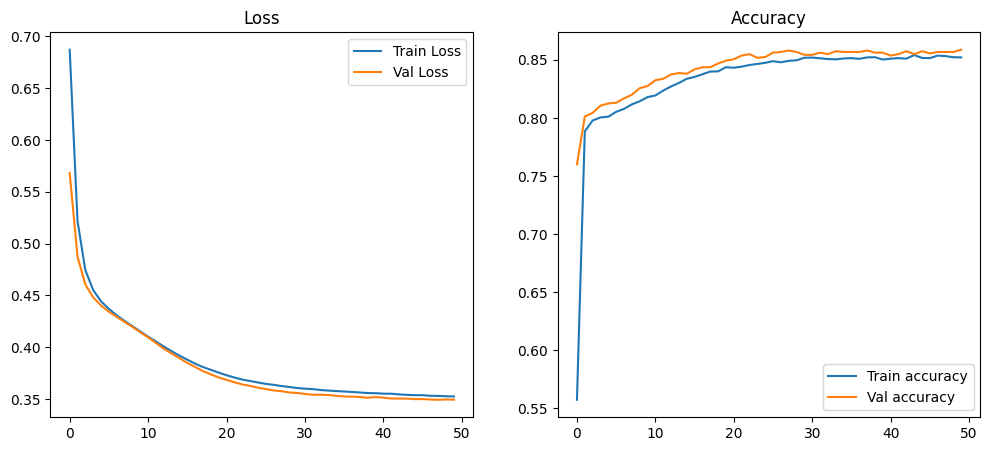

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.legend()
plt.title("Accuracy")

plt.show()

#### The training and validation loss decrease steadily and converge around 0.35, indicating stable learning behavior. The small gap between the two curves suggests that the model generalizes reasonably well and does not show clear signs of overfitting.

#### Accuracy improves quickly in the early epochs and stabilizes around 85–86% for both training and validation sets. The close alignment between the curves indicates consistent and stable performance of the baseline model.

#### Hyperparameters table

In [19]:
import pandas as pd

hyperparameters = {
    "Parameter": [
        "Model ID",
        "Hidden Layer 1 Units",
        "Hidden Layer 2 Units",
        "Activation Function (Hidden)",
        "Output Activation",
        "Optimizer",
        "Learning Rate",
        "Loss Function",
        "Batch Size",
        "Epochs"
    ],
    "Value": [
        "Model 1 (Baseline)",
        64,
        32,
        "ReLU",
        "Sigmoid",
        "Adam",
        0.001,
        "Binary Crossentropy",
        128,
        50
    ]
}

hp_table = pd.DataFrame(hyperparameters)
hp_table


,Parameter,Value
0,Model ID,Model 1 (Baseline)
1,Hidden Layer 1 Units,64
2,Hidden Layer 2 Units,32
3,Activation Function (Hidden),ReLU
4,Output Activation,Sigmoid
5,Optimizer,Adam
6,Learning Rate,0.001
7,Loss Function,Binary Crossentropy
8,Batch Size,128
9,Epochs,50
